In [ ]:
import os
os.environ['KMP_DUPLICATE_LIB_OK']='True'

import torch
import torch.nn as nn
import torch.nn.init as init
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms as transforms
from PIL import Image
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import copy
import time
from typing import Any, Dict, List, Optional, Tuple, Union
from pathlib import Path
import kagglehub

# Check hardware - if this shows 'cpu', the training will be slow but more stable
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Helper to ensure a directory exists
def _ensure_dir(p):
    Path(p).mkdir(parents=True, exist_ok=True)


In [ ]:
def plot_lr_schedule(
    lr_history: List[float],
    save_path: Optional[str] = None,
    title: str = "Learning Rate Decay vs. Epochs",
) -> None:
    """Plot the learning-rate schedule across training epochs."""
    if save_path is None:
        _ensure_dir(RESULTS_DIR)
        save_path = os.path.join(str(RESULTS_DIR), "lr_schedule.png")

    epochs = list(range(1, len(lr_history) + 1))
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(epochs, lr_history, marker="o", linewidth=2, color="#1f77b4")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Learning Rate")
    ax.set_title(title)
    ax.set_yscale("log")
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    fig.savefig(save_path, dpi=150)
    plt.close(fig)
    print(f"LR schedule plot saved → {save_path}")


def plot_training_curves(
    history: Dict[str, List[float]],
    model_name: str = "model",
    save_dir: Optional[Union[str, Path]] = None,
) -> None:
    """Plot train/val loss and accuracy curves side by side."""
    if save_dir is None:
        save_dir = RESULTS_DIR
    _ensure_dir(save_dir)

    epochs = list(range(1, len(history["train_loss"]) + 1))
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Loss
    ax1.plot(epochs, history["train_loss"], label="Train Loss")
    ax1.plot(epochs, history["val_loss"], label="Val Loss")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")
    ax1.set_title(f"{model_name} — Loss")
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Accuracy
    ax2.plot(epochs, history["train_acc"], label="Train Acc")
    ax2.plot(epochs, history["val_acc"], label="Val Acc")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Accuracy (%)")
    ax2.set_title(f"{model_name} — Accuracy")
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    fig.tight_layout()
    fname = Path(save_dir) / f"{model_name}_curves.png"
    fig.savefig(str(fname), dpi=150)
    plt.close(fig)
    print(f"Training curves saved → {fname}")


In [ ]:
# Weight-initialisation helper
# Apply Kaiming (He) uniform initialisation to every Conv2d and Linear layer in model.
def _apply_kaiming_init(model: nn.Module) -> None:
    for m in model.modules():
        w = getattr(m, 'weight', None)
        b = getattr(m, 'bias', None)
        if isinstance(m, (nn.Conv2d, nn.Linear)):
            if w is not None:
                init.kaiming_uniform_(w, nonlinearity="relu")
            if b is not None:
                init.zeros_(b)
        elif isinstance(m, nn.BatchNorm2d):
            if w is not None:
                init.ones_(w)
            if b is not None:
                init.zeros_(b)

# YoLo copy -- Cats Only Bark Once
class coboCNN(nn.Module):
    def __init__(self, num_classes: int = 2):
        super().__init__()
        
        
        self.cobo = nn.Sequential(
            # dont forget activations
            nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1), 
            nn.BatchNorm2d(16),
            nn.AvgPool2d(kernel_size=2, stride=2, padding=0),
            nn.ReLU(),
            
            nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(32),
            nn.AvgPool2d(kernel_size=2, stride=2, padding=0),
            nn.ReLU(),
            
            nn.Conv2d(32,64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.AvgPool2d(kernel_size=2, stride=2, padding=0),
            nn.ReLU(),
            
            nn.Conv2d(64,64,kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.AvgPool2d(kernel_size=2, stride=2, padding=0),
            nn.ReLU(),
            
            nn.Conv2d(64, 32, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(32),
        )
        
        # LeNet-5 Original classifier
        self.classifier = nn.Sequential(
            
            nn.ReLU(),
            nn.Dropout2d(0.2),
            nn.Linear(1_568, 512),
            nn.Sigmoid(),
            nn.Linear(512, 343),
        )

        # Apply initialization
        self._apply_kaiming_init()
        
    def _apply_kaiming_init(self):
        for m in self.modules():
            if isinstance(m, (nn.Conv2d, nn.Linear)):
                w = getattr(m, 'weight', None)
                b = getattr(m, 'bias', None)
                if w is not None:
                    nn.init.kaiming_uniform_(w, nonlinearity='relu')
                if b is not None:
                    nn.init.constant_(b, 0)
            else:
                b = getattr(m, 'bias', None)
                if b is not None:
                    try:
                        nn.init.constant_(b, 0)
                    except Exception:
                        pass

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.cobo(x)
        x = x.view(x.size(0), -1) # Flattens feature maps
        x = self.classifier(x)
        return x


In [ ]:
# Download the dataset locally
dataset_dir = Path(kagglehub.dataset_download("andrewmvd/dog-and-cat-detection"))
print(f"Dataset downloaded to: {dataset_dir.resolve()}")

# Preview top-level files/folders.
for item in sorted(dataset_dir.iterdir()):
    print(f"- {item.name}")

In [ ]:
# Try to import refactored utilities from repo; fallback to definitions below
try:
    import importlib
    dp = importlib.import_module('src.data_processing')
    resize_and_pad_image = dp.resize_and_pad_image
    transform_bbox = dp.transform_bbox
    process_record = dp.process_record
    split_train_val = dp.split_train_val
    visualize_sample = dp.visualize_sample
except Exception:
    from sklearn.model_selection import train_test_split
    from tqdm import tqdm
    import random
    import xml.etree.ElementTree as ET

    def _get_bilinear():
        try:
            return Image.Resampling.BILINEAR
        except Exception:
            return getattr(Image, 'BILINEAR', 2)

    def resize_and_pad_image(img: Image.Image, size=(112,112)):
        W,H = size; w,h = img.size
        scale = min(W/w, H/h)
        new_w = max(1, int(round(w*scale)))
        new_h = max(1, int(round(h*scale)))
        img_resized = img.resize((new_w, new_h), resample=_get_bilinear())
        pad_left = (W - new_w) // 2; pad_top = (H - new_h) // 2
        canvas = Image.new("RGB", (W, H), (0,0,0))
        canvas.paste(img_resized, (pad_left, pad_top))
        return canvas, scale, pad_left, pad_top

    def transform_bbox(bbox, scale, pad_left, pad_top):
        xmin, ymin, xmax, ymax = bbox
        return (
            max(0, int(round(xmin*scale + pad_left))),
            max(0, int(round(ymin*scale + pad_top))),
            max(0, int(round(xmax*scale + pad_left))),
            max(0, int(round(ymax*scale + pad_top)))
        )

    def process_record(image_path, bbox, out_path, size=(112,112)):
        img = Image.open(image_path).convert("RGB")
        orig_w, orig_h = img.size
        canvas, scale, pad_left, pad_top = resize_and_pad_image(img, size=size)
        xmin, ymin, xmax, ymax = transform_bbox(bbox, scale, pad_left, pad_top)
        out_path.parent.mkdir(parents=True, exist_ok=True)
        canvas.save(out_path)
        return {
            "image_path": str(out_path),
            "orig_w": orig_w,
            "orig_h": orig_h,
            "scale": float(scale),
            "pad_left": int(pad_left),
            "pad_top": int(pad_top),
            "xmin": int(xmin),
            "ymin": int(ymin),
            "xmax": int(xmax),
            "ymax": int(ymax)
        }

    def split_train_val(df, stratify_col="label", val_frac=0.2, random_state=42):
        if stratify_col in df.columns:
            t, v = train_test_split(df, test_size=val_frac, stratify=df[stratify_col], random_state=random_state)
        else:
            t, v = train_test_split(df, test_size=val_frac, random_state=random_state)
        return t.reset_index(drop=True), v.reset_index(drop=True)

    def visualize_sample(img_path, bbox, ax=None, show=False):
        if ax is None:
            fig, ax = plt.subplots()
        img = plt.imread(img_path)
        ax.imshow(img)
        import matplotlib.patches as patches
        xmin, ymin, xmax, ymax = bbox
        rect = patches.Rectangle((xmin, ymin), xmax-xmin, ymax-ymin,
                                 linewidth=2, edgecolor='r', facecolor='none')
        ax.add_patch(rect)
        if show:
            plt.show()


In [ ]:
dataset_dir = Path(kagglehub.dataset_download("andrewmvd/dog-and-cat-detection"))
print("Dataset dir:", dataset_dir.resolve())
for p in sorted(dataset_dir.iterdir()):
    print("-", p.name)


In [ ]:
for p in dataset_dir.rglob("*.csv"):
    df_check = pd.read_csv(p, nrows=0) # Only reads header
    print(f"File: {p.name} | Columns: {list(df_check.columns)}")

In [ ]:
# Find all XML files
xml_files = list(dataset_dir.rglob("*.xml"))
print(f"Found {len(xml_files)} XML files.")

data = []

for xml_path in tqdm(xml_files, desc="Processing XMLs"):
    try:
        tree = ET.parse(xml_path)
        root = tree.getroot()
    except Exception:
        continue

    fname_node = root.find('filename')
    file_name = fname_node.text if fname_node is not None and fname_node.text else Path(xml_path).stem

    for obj in root.findall('object'):
        name_node = obj.find('name')
        label = name_node.text if name_node is not None and name_node.text else 'unknown'
        bbox = obj.find('bndbox')
        if bbox is None:
            continue

        xmin_n = bbox.find('xmin')
        ymin_n = bbox.find('ymin')
        xmax_n = bbox.find('xmax')
        ymax_n = bbox.find('ymax')
        if None in (xmin_n, ymin_n, xmax_n, ymax_n):
            continue

        try:
            xmin = int(getattr(xmin_n, 'text', '0') or '0')
            ymin = int(getattr(ymin_n, 'text', '0') or '0')
            xmax = int(getattr(xmax_n, 'text', '0') or '0')
            ymax = int(getattr(ymax_n, 'text', '0') or '0')
        except Exception:
            continue

        data.append({
            'filename': file_name,
            'class': label,
            'xmin': xmin,
            'ymin': ymin,
            'xmax': xmax,
            'ymax': ymax
        })

# 3. Create the DataFrame
df = pd.DataFrame(data)
print(f"\nLoaded annotations shape: {df.shape}")
print(df.head())


In [ ]:
# Expected final columns: image, label, xmin, ymin, xmax, ymax
colmap = {}
if 'file_name' in df.columns and 'label' in df.columns: colmap['file_name'] = 'image'
if 'image' not in df.columns: colmap[df.columns[0]] = 'image'
if 'class' in df.columns: colmap['class'] = 'label'
if 'x1' in df.columns: colmap['x1'] = 'xmin'
if 'y1' in df.columns: colmap['y1'] = 'ymin'
if 'x2' in df.columns: colmap['x2'] = 'xmax'
if 'y2' in df.columns: colmap['y2'] = 'ymax'
df = df.rename(columns=colmap)
required = {'image','label','xmin','ymin','xmax','ymax'}
if not required.issubset(set(df.columns)):
    raise ValueError(f"Annotations missing required columns: {required - set(df.columns)}")
# make image paths absolute if necessary
df['image'] = df['image'].apply(lambda p: str((dataset_dir / p) if not Path(p).is_absolute() else Path(p)))

In [ ]:
train_df, val_df = split_train_val(df, stratify_col='label', val_frac=0.2, random_state=42)
print("Train/Val sizes:", len(train_df), len(val_df))

In [ ]:
# check if we have any overlap between train and val sets
overlap = set(train_df['image']) & set(val_df['image'])
print(f"Number of overlapping images: {len(overlap)}")
# should be 0

In [ ]:
# Define output paths
out_dir = Path("data/processed")
train_out_dir = out_dir / "train"
val_out_dir = out_dir / "val"

# Ensure directories exist
train_out_dir.mkdir(parents=True, exist_ok=True)
val_out_dir.mkdir(parents=True, exist_ok=True)

train_rows = []
val_rows = []

def process_df_rows(df_in, dst_dir, rows_out):
    pbar = tqdm(df_in.iterrows(), total=len(df_in), desc=f"Processing {dst_dir.name}")
    
    for i, r in pbar:
        img_path = dataset_dir / "images" / Path(r['image']).name
        
        if not img_path.exists():
            continue
            
        fname = img_path.name
        dst = dst_dir / fname
        bbox = (float(r['xmin']), float(r['ymin']), float(r['xmax']), float(r['ymax']))
        
        meta = process_record(img_path, bbox, dst, size=(112, 112))
        
        meta['label'] = r['label']
        rows_out.append(meta)

# Run processing for both splits
process_df_rows(train_df, train_out_dir, train_rows)
process_df_rows(val_df, val_out_dir, val_rows)

# Create new DataFrames and save to CSV
train_processed_df = pd.DataFrame(train_rows)
val_processed_df = pd.DataFrame(val_rows)

train_processed_df.to_csv(out_dir / "train.csv", index=False)
val_processed_df.to_csv(out_dir / "val.csv", index=False)

print(f"Successfully saved {len(train_processed_df)} train and {len(val_processed_df)} val records.")
print(f"Processed data located at: {out_dir.resolve()}")

# Create a combined processed dataframe for visualization and quick checks
proc_df = pd.concat([train_processed_df, val_processed_df], ignore_index=True)
print(f"Combined processed dataframe rows: {len(proc_df)}")

# Minimal training helpers and imports to satisfy notebook flow
from torch.optim import Adam, SGD, RMSprop
from torch.optim.lr_scheduler import StepLR

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)
        optimizer.zero_grad()
        outputs = model(xb)
        loss = criterion(outputs, yb)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * xb.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == yb).sum().item()
        total += xb.size(0)
    return (running_loss / total) if total > 0 else 0.0, (100.0 * correct / total) if total > 0 else 0.0


def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)
            outputs = model(xb)
            loss = criterion(outputs, yb)
            running_loss += loss.item() * xb.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == yb).sum().item()
            total += xb.size(0)
    return (running_loss / total) if total > 0 else 0.0, (100.0 * correct / total) if total > 0 else 0.0


In [ ]:
# Setup sample data
num_samples = min(8, len(proc_df))
indices = random.sample(range(len(proc_df)), num_samples)

# Create the figure and grid (2 rows, 4 columns)
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()  # Flatten to easily loop with a single index

for i, idx in enumerate(indices):
    row = proc_df.iloc[idx]
    img_p = Path(row['image_path'])
    bbox = (int(row['xmin']), int(row['ymin']), int(row['xmax']), int(row['ymax']))
    visualize_sample(img_p, bbox, ax=axes[i])
    axes[i].set_title(f"Class: {row.get('label', 'N/A')}")

# Clean up layout
plt.tight_layout()
plt.show()

In [ ]:
def train_model(
    model_class,
    train_loader: DataLoader,
    val_loader: DataLoader,
    device: torch.device,
    best_hyperparams: Dict[str, Any],
    epochs: int = 20,
) -> Tuple[nn.Module, Dict[str, List[float]]]:
    
    opt_name = best_hyperparams["optimizer"]
    lr = best_hyperparams["learning_rate"]
    wd = best_hyperparams["weight_decay"]
    bs = best_hyperparams["batch_size"]

    # History dictionary for plotting
    history = {
        "train_loss": [], "val_loss": [],
        "train_acc": [], "val_acc": [],
        "lr": []
    }

    # Update data loaders if batch size changed
    train_loader_new = train_loader
    val_loader_new = val_loader
    if bs != train_loader.batch_size:
        train_loader_new = DataLoader(
            train_loader.dataset, batch_size=bs, shuffle=True,
            num_workers=getattr(train_loader, "num_workers", 0), pin_memory=True
        )
        val_loader_new = DataLoader(
            val_loader.dataset, batch_size=bs, shuffle=False,
            num_workers=getattr(val_loader, "num_workers", 0), pin_memory=True
        )

    model = model_class()
    model.to(device)

    if opt_name.lower() == "adam":
        optimizer = Adam(model.parameters(), lr=lr, weight_decay=wd)
    elif opt_name.lower() == "sgd":
        optimizer = SGD(model.parameters(), lr=lr, weight_decay=wd, momentum=0.9)
    elif opt_name.lower() == "rmsprop":
        optimizer = RMSprop(model.parameters(), lr=lr, weight_decay=wd)
    else:
        raise ValueError(f"Unsupported optimizer: {opt_name}")

    criterion = nn.CrossEntropyLoss()
    scheduler = StepLR(optimizer, step_size=5, gamma=0.5)

    best_val_acc = 0.0
    best_weights = None

    for epoch in range(epochs):
        t0 = time.time()
        
        train_loss, train_acc = train_one_epoch(model, train_loader_new, criterion, optimizer, device)
        val_loss, val_acc = evaluate(model, val_loader_new, criterion, device)
        
        current_lr = optimizer.param_groups[0]["lr"]
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)
        history["lr"].append(current_lr)

        scheduler.step()
        
        elapsed = time.time() - t0
        print(f"Epoch {epoch + 1:>3d}/{epochs} | LR {current_lr:.6f} | "
              f"Train Loss {train_loss:.4f} Acc {train_acc:6.2f}% | "
              f"Val Loss {val_loss:.4f} Acc {val_acc:6.2f}% | {elapsed:.1f}s")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_weights = copy.deepcopy(model.state_dict())

    if best_weights is not None:
        model.load_state_dict(best_weights)
        print(f"Restored best model with validation accuracy: {best_val_acc:.2f}%")
        
    return model, history

In [ ]:
# Train final model with best hyperparameters from search
def train_final_model(
    model_class,
    train_loader: DataLoader,
    val_loader: DataLoader,
    device: torch.device,
    best_hyperparams: Dict[str, Any],
    epochs: int = 20,
) -> nn.Module:
    """
    Train the final model using the best hyperparameters found in the search.
    """
    opt_name = best_hyperparams["optimizer"]
    lr = best_hyperparams["learning_rate"]
    wd = best_hyperparams["weight_decay"]
    bs = best_hyperparams["batch_size"]

    print(f"Training final model with hyperparameters:")
    print(f"Optimizer: {opt_name}, LR: {lr}, Weight Decay: {wd}, Batch Size: {bs}")

    # Update data loaders if batch size changed
    if bs != train_loader.batch_size:
        train_loader_new = DataLoader(
            train_loader.dataset,
            batch_size=bs,
            shuffle=True,
            num_workers=getattr(train_loader, "num_workers", 0),
            pin_memory=True,
        )
        val_loader_new = DataLoader(
            val_loader.dataset,
            batch_size=bs,
            shuffle=False,
            num_workers=getattr(val_loader, "num_workers", 0),
            pin_memory=True,
        )
    else:
        train_loader_new = train_loader
        val_loader_new = val_loader

    # Create model
    model = model_class()
    model.to(device)

    # Setup optimizer
    if opt_name.lower() == "adam":
        optimizer = Adam(model.parameters(), lr=lr, weight_decay=wd)
    elif opt_name.lower() == "sgd":
        optimizer = SGD(model.parameters(), lr=lr, weight_decay=wd, momentum=0.9)
    elif opt_name.lower() == "rmsprop":
        optimizer = RMSprop(model.parameters(), lr=lr, weight_decay=wd)
    else:
        raise ValueError(f"Unsupported optimizer: {opt_name}")

    # Setup loss and scheduler
    criterion = nn.CrossEntropyLoss()
    scheduler = StepLR(optimizer, step_size=5, gamma=0.5)

    best_val_acc = 0.0
    best_weights = None

    for epoch in range(epochs):
        t0 = time.time()
        train_loss, train_acc = train_one_epoch(model, train_loader_new, criterion, optimizer, device)
        val_loss, val_acc = evaluate(model, val_loader_new, criterion, device)
        scheduler.step()
        elapsed = time.time() - t0
        current_lr = optimizer.param_groups[0]["lr"]
        print(
            f"Epoch {epoch + 1:>3d}/{epochs} | "
            f"LR {current_lr:.6f} | "
            f"Train Loss {train_loss:.4f}  Acc {train_acc:6.2f}% | "
            f"Val Loss {val_loss:.4f}  Acc {val_acc:6.2f}% | "
            f"{elapsed:.1f}s"
        )
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_weights = copy.deepcopy(model.state_dict())
    if best_weights is not None:
        model.load_state_dict(best_weights)
        print(f"Restored best model with validation accuracy: {best_val_acc:.2f}%")
    return model

In [ ]:
class CatDogDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        try:
            # Load image only when requested
            img_path = self.image_paths[idx]
            image = Image.open(img_path).convert("RGB")
            label = self.labels[idx]
            if self.transform:
                image = self.transform(image)
            return image, label
        except Exception as e:
            # If an image is corrupt, return a blank tensor instead of crashing
            return torch.zeros((3, 112, 112)), self.labels[idx]

# Define basic transforms
transform = transforms.Compose([
    transforms.Resize((112, 112)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [ ]:
# Build train/val file lists and numeric labels from processed data
combined = pd.concat([train_processed_df, val_processed_df], ignore_index=True)
labels = sorted(combined['label'].unique())
label_map = {lab: i for i, lab in enumerate(labels)}

train_files = train_processed_df['image_path'].tolist()
train_labels = train_processed_df['label'].map(label_map).tolist()
val_files = val_processed_df['image_path'].tolist()
val_labels = val_processed_df['label'].map(label_map).tolist()

# Create datasets
train_dataset = CatDogDataset(train_files, train_labels, transform=transform)
val_dataset = CatDogDataset(val_files, val_labels, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

# Setup device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


In [ ]:
# Define hyperparameters
best_hps = {
    "optimizer": "adam",
    "learning_rate": 0.001,
    "weight_decay": 1e-4,
    "batch_size": 32
}

# Train the model and get history
final_model, history = train_model(
    coboCNN, # Use your original model class name
    train_loader, 
    val_loader, 
    device, 
    best_hps, 
    epochs=20
)

# Plot the results
plot_training_curves(history, model_name="coboCNN_Final")
plot_lr_schedule(history["lr"])

# Save the model weights
torch.save(final_model.state_dict(), os.path.join(RESULTS_DIR, "final_model_weights.pth"))

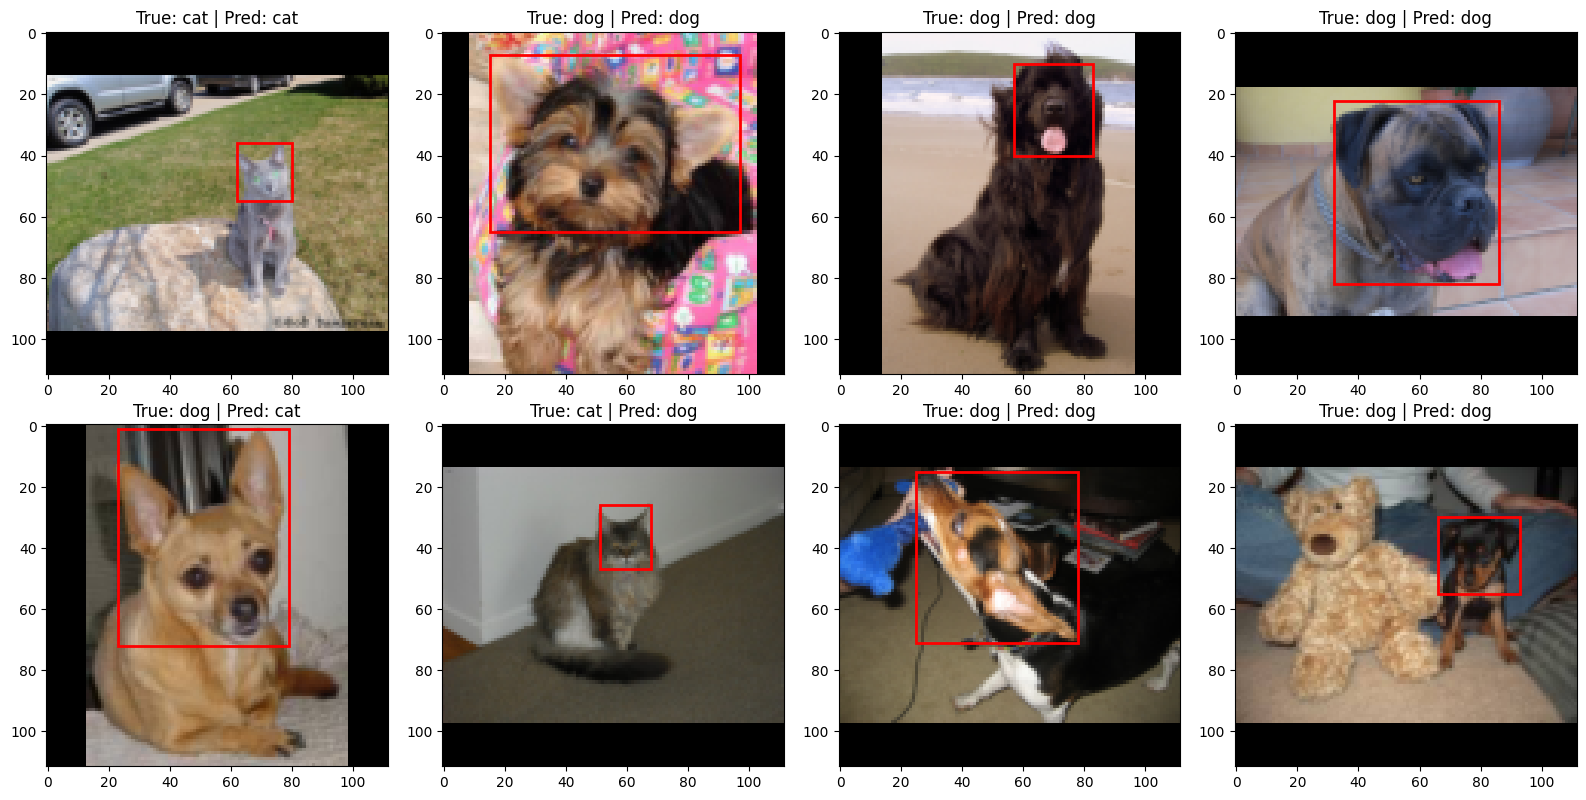

In [ ]:
# test output model on a few samples with the bounding boxes visualized and the index of the predicted class shown under the bounding box. You can use the visualize_sample function defined earlier to draw the bounding boxes on the images, and then display the predicted class index as text on the plot. Here's how you can do it:
num_samples = min(8, len(val_dataset))
indices = random.sample(range(len(val_dataset)), num_samples)
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()
for i, idx in enumerate(indices):
    img_path = val_files[idx]
    label = val_labels[idx]
    # Load and preprocess the image
    image = Image.open(img_path).convert("RGB")
    input_tensor = transform(image).unsqueeze(0).to(device)
    # Get model prediction
    with torch.no_grad():
        output = final_model(input_tensor)
        pred_class_idx = output.argmax(dim=1).item()
    bbox = (
        int(val_processed_df.iloc[idx]['xmin']),
        int(val_processed_df.iloc[idx]['ymin']),
        int(val_processed_df.iloc[idx]['xmax']),
        int(val_processed_df.iloc[idx]['ymax'])
    )
    visualize_sample(img_path, bbox, ax=axes[i])
    axes[i].set_title(f"True: {labels[label]} | Pred: {labels[pred_class_idx]}")

plt.tight_layout()
plt.show()